# Water Potability Prediction — Logistic Regression (6 Features)

This notebook uses the existing `water_potability.csv` dataset.

The model uses exactly six parameters:

1. `ph`
2. `Turbidity`
3. `Hardness`
4. `Solids`
5. `Organic_carbon`
6. `Chloramines`

pH and Turbidity are compulsory features. The other four parameters are selected from the original dataset.

The model uses `class_weight="balanced"` to reduce the tendency to predict only the majority class.


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the existing dataset

DATASET_PATH = "dataset/water_potability.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


Dataset loaded successfully.
Dataset shape: (3276, 10)

Columns:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


In [3]:
# Define the six model features

FEATURES = [
    "ph",
    "Turbidity",
    "Hardness",
    "Solids",
    "Organic_carbon",
    "Chloramines"
]

TARGET = "Potability"

required_columns = FEATURES + [TARGET]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns in dataset: {missing_columns}"
    )

print("All required columns are present.")
print("\nFeatures used:")
print(FEATURES)

print("\nTarget:")
print(TARGET)


All required columns are present.

Features used:
['ph', 'Turbidity', 'Hardness', 'Solids', 'Organic_carbon', 'Chloramines']

Target:
Potability


In [4]:
# Select only the six features and target

model_df = df[FEATURES + [TARGET]].copy()

print("Columns used:")
print(model_df.columns.tolist())

print("\nRows before removing missing values:")
print(len(model_df))


Columns used:
['ph', 'Turbidity', 'Hardness', 'Solids', 'Organic_carbon', 'Chloramines', 'Potability']

Rows before removing missing values:
3276


In [5]:
# Remove rows with missing values

model_df = model_df.dropna().reset_index(drop=True)

X = model_df[FEATURES].copy()
y = model_df[TARGET].copy()

print("Rows after removing missing values:", len(model_df))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nFirst five rows:")
display(X.head())


Rows after removing missing values: 2785
X shape: (2785, 6)
y shape: (2785,)

Target distribution:
Potability
0    1684
1    1101
Name: count, dtype: int64

First five rows:


,ph,Turbidity,Hardness,Solids,Organic_carbon,Chloramines
0,3.716080,4.500656,129.422921,18630.057858,15.180013,6.635246
1,8.099124,3.055934,224.236259,19909.541732,16.868637,9.275884
2,8.316766,4.628771,214.373394,22018.417441,18.436524,8.059332
3,9.092223,4.075075,181.101509,17978.986339,11.558279,6.546600
4,5.584087,2.559708,188.313324,28748.687739,8.399735,7.544869


In [6]:
# Split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 2228
Testing samples: 557


In [7]:
# Standardize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaler fitted successfully.")
print("Feature order:")
print(X_train.columns.tolist())


Scaler fitted successfully.
Feature order:
['ph', 'Turbidity', 'Hardness', 'Solids', 'Organic_carbon', 'Chloramines']


In [8]:
# Train Logistic Regression

# class_weight="balanced" gives both classes appropriate importance
# and helps prevent the model from predicting only the majority class.

model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")
print("Number of features:", model.n_features_in_)
print("Feature order:", FEATURES)


Logistic Regression model trained successfully.
Number of features: 6
Feature order: ['ph', 'Turbidity', 'Hardness', 'Solids', 'Organic_carbon', 'Chloramines']


In [9]:
# Generate predictions

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Actual class distribution:")
print(y_test.value_counts())

print("\nPredicted class distribution:")
print(pd.Series(y_pred).value_counts())

print("\nUnique predicted classes:")
print(np.unique(y_pred))


Actual class distribution:
Potability
0    337
1    220
Name: count, dtype: int64

Predicted class distribution:
0    303
1    254
Name: count, dtype: int64

Unique predicted classes:
[0 1]


In [10]:
# Evaluate the model

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

print("ROC-AUC:", roc_auc)


Accuracy: 0.5080789946140036

Confusion Matrix:
[[183 154]
 [120 100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.54      0.57       337
           1       0.39      0.45      0.42       220

    accuracy                           0.51       557
   macro avg       0.50      0.50      0.50       557
weighted avg       0.52      0.51      0.51       557

ROC-AUC: 0.49707310493660645


In [11]:
# Display feature coefficients

coefficients = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": model.coef_[0]
}).sort_values(
    by="Coefficient",
    ascending=False
).reset_index(drop=True)

display(coefficients)


,Feature,Coefficient
0,Solids,0.094207
1,Chloramines,0.059408
2,Organic_carbon,-0.000865
3,ph,-0.012658
4,Turbidity,-0.017282
5,Hardness,-0.019974


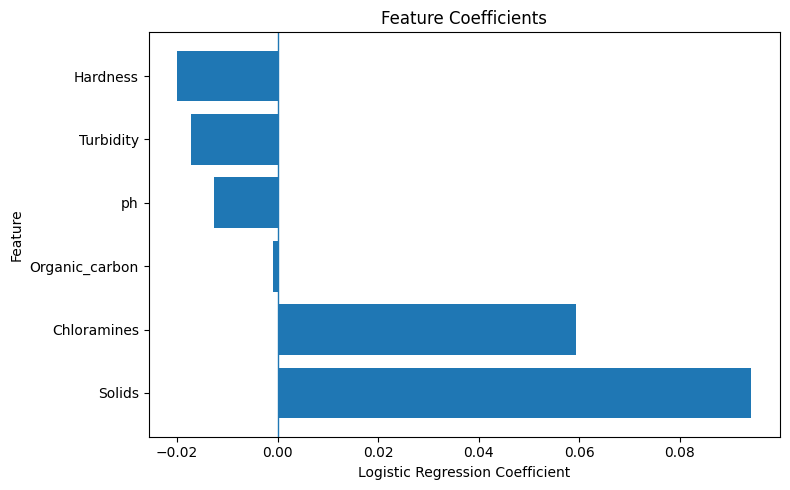

In [12]:
# Plot feature coefficients

plt.figure(figsize=(8, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients")

plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()


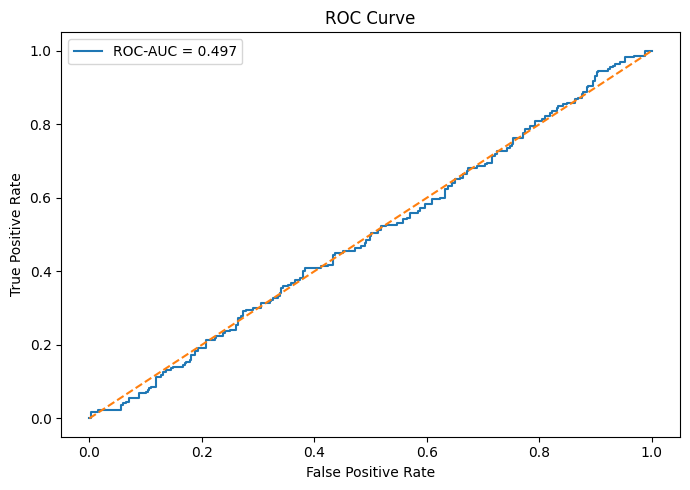

In [13]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Test a sample input

sample = pd.DataFrame([{
    "ph": 7.0,
    "Turbidity": 4.0,
    "Hardness": 200.0,
    "Solids": 25000.0,
    "Organic_carbon": 12.0,
    "Chloramines": 7.0
}])

# Force exact training order
sample = sample[FEATURES]

sample_scaled = scaler.transform(sample)

sample_prediction = int(model.predict(sample_scaled)[0])
sample_probability = float(
    model.predict_proba(sample_scaled)[0][1]
)

print("Sample feature order:")
print(sample.columns.tolist())

print("\nPrediction:", sample_prediction)
print("Potability probability:", sample_probability)

if sample_prediction == 1:
    print("Result: Potable")
else:
    print("Result: Not potable")


Sample feature order:
['ph', 'Turbidity', 'Hardness', 'Solids', 'Organic_carbon', 'Chloramines']

Prediction: 1
Potability probability: 0.506231926907062
Result: Potable


In [15]:
# Save the model, scaler, and feature order

MODEL_PATH = "logistic_model.pkl"
SCALER_PATH = "scaler.pkl"
FEATURES_PATH = "model_features.pkl"

joblib.dump(model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(FEATURES, FEATURES_PATH)

print("Files saved successfully:")
print(os.path.abspath(MODEL_PATH))
print(os.path.abspath(SCALER_PATH))
print(os.path.abspath(FEATURES_PATH))


Files saved successfully:
D:\ProjectClg\MLModel\logistic_model.pkl
D:\ProjectClg\MLModel\scaler.pkl
D:\ProjectClg\MLModel\model_features.pkl


In [16]:
# FINAL VERIFICATION

loaded_model = joblib.load(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)
loaded_features = joblib.load(FEATURES_PATH)

print("Loaded feature order:")
print(loaded_features)

print("\nModel feature count:")
print(loaded_model.n_features_in_)

print("\nScaler feature count:")
print(loaded_scaler.n_features_in_)

assert loaded_features == FEATURES
assert loaded_model.n_features_in_ == 6
assert loaded_scaler.n_features_in_ == 6

# Verify the saved model can process a six-feature input
test_input = pd.DataFrame([{
    "ph": 7.0,
    "Turbidity": 4.0,
    "Hardness": 200.0,
    "Solids": 25000.0,
    "Organic_carbon": 12.0,
    "Chloramines": 7.0
}])

test_input = test_input[loaded_features]

test_scaled = loaded_scaler.transform(test_input)
test_prediction = int(loaded_model.predict(test_scaled)[0])

print("\nFINAL VERIFICATION PASSED.")
print("Saved model prediction:", test_prediction)

print("\nCopy these three files to your Flask server:")
print("- logistic_model.pkl")
print("- scaler.pkl")
print("- model_features.pkl")


Loaded feature order:
['ph', 'Turbidity', 'Hardness', 'Solids', 'Organic_carbon', 'Chloramines']

Model feature count:
6

Scaler feature count:
6

FINAL VERIFICATION PASSED.
Saved model prediction: 1

Copy these three files to your Flask server:
- logistic_model.pkl
- scaler.pkl
- model_features.pkl


## Flutter Input Order

Your Flutter/API code must send these six fields:

```text
ph
Turbidity
Hardness
Solids
Organic_carbon
Chloramines
```

The Flask API must create the input DataFrame in exactly this order before calling `scaler.transform()`.

Do not mix these newly generated files with older 5-feature or 9-feature `.pkl` files.
